In [7]:
# Pair, linked-list, and Source Academy compatibility helpers are defined here.

import math

class Pair(tuple):
    """A Source Academy-style pair that also supports head/tail selectors."""

    def __new__(cls, head_value, tail_value):
        return super().__new__(cls, (head_value, tail_value))

    def __call__(self, selector):
        return selector(self[0], self[1])


def pair(head_value, tail_value):
    return Pair(head_value, tail_value)


def head(p):
    return p(lambda head_value, tail_value: head_value)


def tail(p):
    return p(lambda head_value, tail_value: tail_value)


def is_none(value):
    return value is None


def is_pair(value):
    return isinstance(value, Pair)


def llist(*values):
    result = None
    for value in reversed(values):
        result = pair(value, result)
    return result


def is_llist(value):
    current = value
    while is_pair(current):
        current = tail(current)
    return is_none(current)

def enum_llist(start, end):
    result = None
    for value in range(end, start - 1, -1):
        result = pair(value, result)
    return result

def print_llist(xs):
    values = []
    while not is_none(xs):
        values.append(str(head(xs)))
        xs = tail(xs)
    print(f"llist({', '.join(values)})")

def length(xs):
    return 0 if is_none(xs) else 1 + length(tail(xs))

def append(xs, ys):
    return (ys 
            if is_none(xs)
            else pair(head(xs), append(tail(xs), ys)))

details! <br>
All core material up to and including Week 5's Lectures, Paths, Missions, Reflections, Studios. <br>
probably includes curves & sound so gotta study allat... <br>

basically im gna make the cheatsheet here and copy paste from here later.

# PRACTICE A

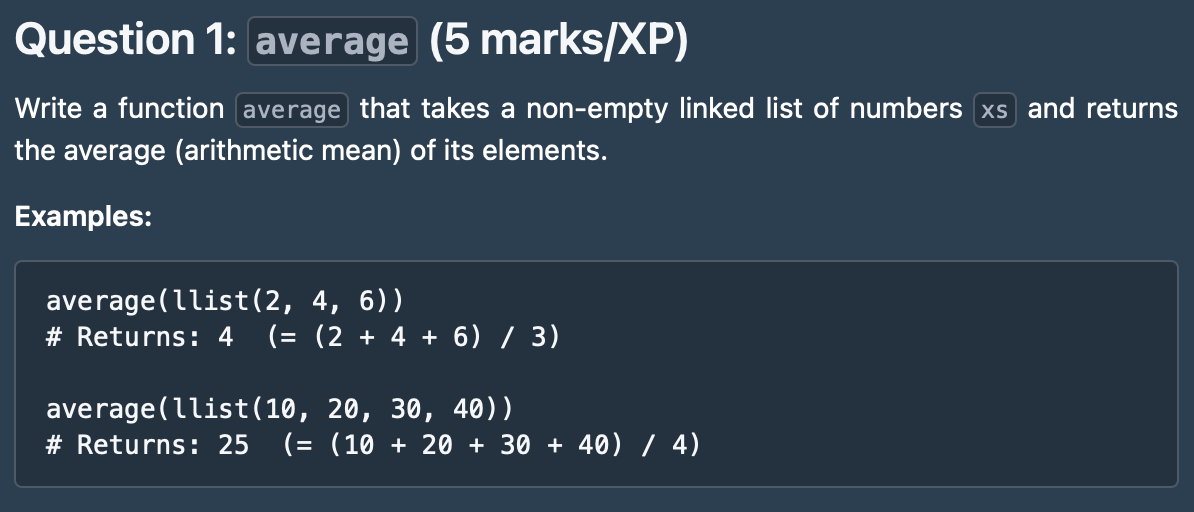

ok i fucking hate telling him hes smart and feeding his ego but this was smart only <br>
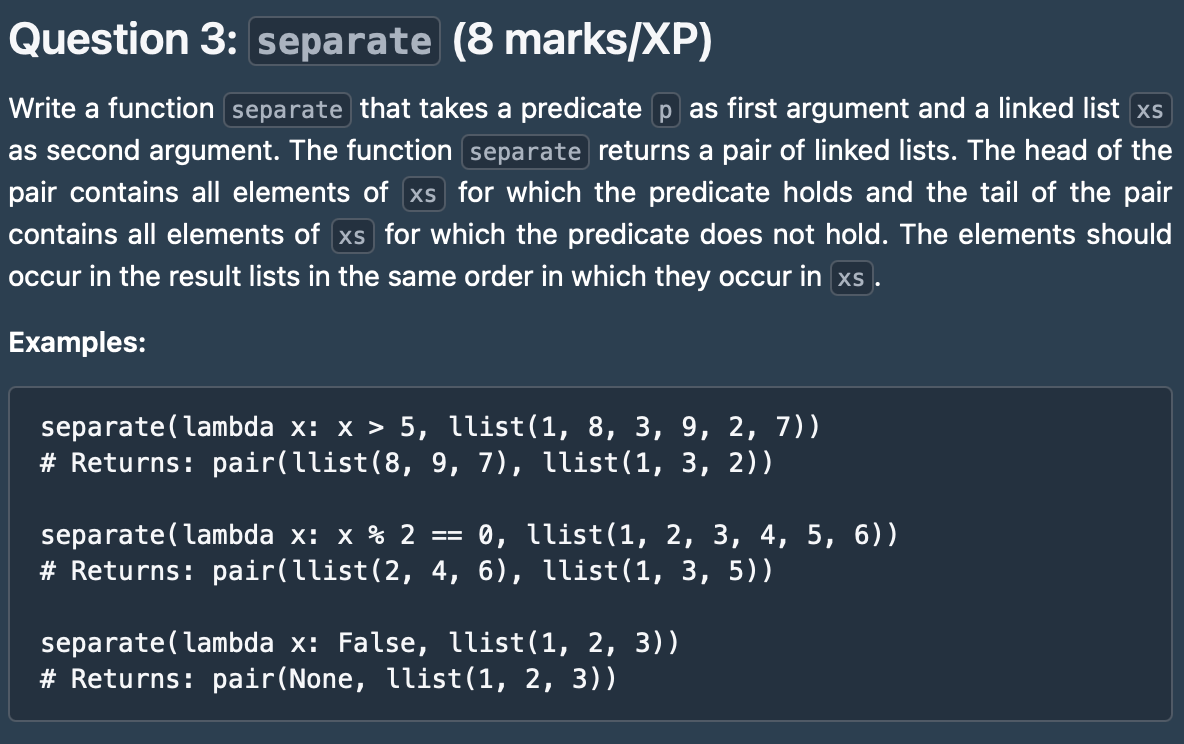

In [17]:
# my solution
def helper(x, ys): #want to check if am element x is not in ys
    if is_none(ys): return True
    elif x==head(ys): return False
    else: return helper(x, tail(ys))
    
def separate(p, xs):
    head = filter(p, xs)
    tail = filter(lambda x: helper(x, head), xs) #check if not in head
    return pair(head, tail)

# alternative solution (nandan's) (stfu this guy is too cracked im killing myself)

def separate2(p, xs):
    def helper2(fulfils, doesnt, p, xs): 
        if is_none(xs): 
            return pair(fulfils, doesnt)
        elif p(head(xs)): 
            return helper2(append(fulfils, llist(head(xs))), doesnt, p, tail(xs))
        else:
            return helper2(fulfils, append(doesnt, llist(head(xs))), p, tail(xs))
    return helper2(None, None, p, xs)